In [1]:
import os
import glob
import json
import yaml

import numpy as np
from tqdm import tqdm

import cv2
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as mPolygon

from shapely.geometry import Polygon as sPolygon
from shapely.validation import make_valid

In [2]:
subset = 'train'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
vgg_annotations_path = r"/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG"

yaml_file = os.path.join(dataset_path, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(dataset_path, subset, 'images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
new_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels')
vgg_annotations = glob.glob(os.path.join(vgg_annotations_path, "*", "*")) # glob.glob(r"/home/c/choton/beemachine/everyday_test/sep26_25/partwhole_yolo_original/VGG/*/*")

images = os.listdir(images_dir)
yolo_labels = os.listdir(yolo_labels_dir)

In [3]:
# Load class names from YAML
with open(yaml_file, "r") as f:
    data = yaml.safe_load(f)
class_names = data["names"]
print("class names:", class_names)

# Load vgg annotations
vgg1 = os.path.basename(vgg_annotations[0])[:-5]
print("sample vgg annotations \n", vgg_annotations[:5])
print("sample vgg search name", vgg1)
print(f"Total images: {len(images)}, Total YOLO annotations: {len(yolo_labels)}, Total VGG annotations: {len(vgg_annotations)}")
print("sample images: ", images[:5])

class names: ['abdomen', 'head', 'thorax']
sample vgg annotations 
 ['/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG/Bombus_kluanensis/Bombus_kluanensis_GBIF_iNat_3355305657_1.jpg.json', '/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG/Bombus_consobrinus/Bombus_consobrinus_iNat_58327530_01.jpg.json', '/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG/Bombus_consobrinus/Bombus_consobrinus_iNat_27319014_01.jpg.json', '/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG/Bombus_consobrinus/Bombus_consobrinus_iNat_52536175_01.jpg.json', '/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG/Bombus_consobrinus/Bombus_consobrinus_iNat_50784690_1.jpg.json']
sample vgg search name Bombus_kluanensis_GBIF_iNat_3355305657_1.jpg
Total images: 5787, Total YOLO annotations: 5787, Total VGG annotations: 8033
sample images:  ['Bombus_bifarius_57968807_1_1_jpg.rf.623e79744879b9812e9d7abaec75cb74.jpg', 'Bombus_polaris_GBIF_iNat_3384911150_7-jpg_j

In [4]:
# Build vgg_dict efficiently
vgg_name_to_path = {}
for vgg_ann in vgg_annotations:
    name = os.path.basename(vgg_ann)[:-5]
    name = name.replace("._", "-_")
    name = name.replace(".jpg", "")
    if name in vgg_name_to_path:
        print(f"Duplicate VGG name: {name}")
    vgg_name_to_path[name] = vgg_ann

vgg_dict = {}
vgg_count = 0
for img in images:
    matched = False
    for name in list(vgg_name_to_path.keys()):
        if name in img:
            if matched:
                print("Duplicate match for image:", img)
            vgg_dict[img] = vgg_name_to_path[name]
            vgg_count += 1
            matched = True
vgg_count

Duplicate VGG name: AZGLNZ8L5ZNHBHIHBHIHOH4HBHXH1HHL5Z7H8ZSLCHKLVH7H5ZSL6ZXHTHNH1ZGLYHUHCH9HFHMLVZ9HHR9H1ZPH1H4H
Duplicate VGG name: AL0ZTLQZNL5RFZIRTZIROZ5RTZJLPLSRCZKROZSRCZIR3ZZZTZZZULJLDZIROZ7RFZMR2LJL9LJL9LZZWLSRULQR2L
Duplicate VGG name: U0S0E0K0M0JR3KAR3KARFKCR3KTQP0DRQQTRJKNR3K9RM01RMQOR60S0SQ00N0H0IQDRE00060FRRQARLQVRG0BRLQ
Duplicate VGG name: HZ9LYLWLKZYZ4RZHERZHPRJZERZHERCLGRDZSRPLQRTZSR9LIROZZZYZZZTZ0RRHPRRH8RZH7ZRHGRCZYLWLZZDZGR
Duplicate match for image: Bombus_distinguendus_GBIF_iNat_3325576534_20-jpg_jpg.rf.7be4c30111f7b2340b3b6e230acb1c5e.jpg
Duplicate match for image: Bombus_opifex_GBIF_iNat_2596092695_16-jpg_jpg.rf.2a51654f2f5a6611240c115fd6619b5c.jpg
Duplicate match for image: BBW_Bombus_sandersoni_44399_1b5325c0-5c30-47dc-bede-f58f927ac2e6_1_jpg.rf.cec1e666113a7b0fb011cc9d886225c4.jpg
Duplicate match for image: Bombus_distinguendus_GBIF_iNat_3325576534_15-jpg_jpg.rf.6fed9f86c4e52a4448c17027292416c7.jpg
Duplicate match for image: Bombus_morio_GBIF_iNat_2576312696_10

5811

In [5]:
# Check how many vgg annotations are found for the set
images_found = list(vgg_dict.keys())
images_not_found = list(set(images)-set(images_found))
print(f"Total images in original dataset: {len(images)}")
print(f"Total vgg annotations found: {len(images_found)}") 
print(f"Images not found: {len(images_not_found)}")

Total images in original dataset: 5787
Total vgg annotations found: 5787
Images not found: 0


In [6]:
# Read VGG annotation and return mask
def read_vgg_annotation(vgg_annotation_path, width, height):
    with open(vgg_annotation_path, 'r') as f:
        vgg_data = json.load(f)
    image_name = list(vgg_data.keys())[0]
    if 'regions' in vgg_data[image_name].keys():
        x = vgg_data[image_name]['regions']['0']['shape_attributes']['all_points_x']
        y = vgg_data[image_name]['regions']['0']['shape_attributes']['all_points_y']
    else:
        return None, None
    
    true_mask = Image.new('L', (width, height), 0)
    draw = ImageDraw.Draw(true_mask)
    polygon = list(zip(x, y))
    draw.polygon(polygon, outline=1, fill=1)
    return polygon, true_mask

def read_vgg_annotation_special(vgg_label_path): # Special function to handle other vgg annotations
    with open(vgg_label_path) as f:
        data = json.load(f)
    
    # Get image info
    img_info = data["images"][0]
    width, height = img_info["width"], img_info["height"]

    # Create an empty mask
    mask = np.zeros((height, width), dtype=np.uint8)

    # Loop through annotations
    for ann in data["annotations"]:
        segmentation = ann["segmentation"][0]  # VIA stores polygon as [x1,y1,x2,y2,...]
        
        # Convert into Nx2 array of coordinates
        polygon = np.array(segmentation).reshape(-1, 2).astype(np.int32)
        
        # Fill the polygon on the mask
        cv2.fillPoly(mask, [polygon], color=1)  # 1 for foreground
        
    mask = Image.fromarray(mask)
    return polygon, mask

In [7]:
# Function to plot yolo annotation
def plot_yolo_annotation(image_path, label_path, ax):
    image = Image.open(image_path)
    w, h = image.size

    # Read YOLO segmentation annotations
    annotations = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            # Convert normalized coords → pixel coords
            poly = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]
            annotations.append((cls_id, poly))

    # Plot
    ax.imshow(image)
    ax.set_title("Original partwhole annotations")
    np.random.seed(30)
    class_colors = {cls_id: np.random.rand(3,) for cls_id, _ in annotations}
    for cls_id, poly in annotations:
        polygon = mPolygon(poly, closed=True, edgecolor=class_colors[cls_id], fill=False, linewidth=2)
        ax.add_patch(polygon)
        # Label
        x, y = poly[0]
        label = f"{cls_id, class_names[cls_id]}"
        ax.text(x, y, label, 
                color=class_colors[cls_id], fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
        
def plot_vgg_annotation(image, mask, ax):
    ax.set_title("Full-body annotation")
    ax.imshow(image)
    ax.imshow(mask, alpha=0.5)

# Function to plot yolo annotation
def get_yolo_polygons(label_path, w, h):
    # Read YOLO segmentation annotations
    annotations = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            # Convert normalized coords → pixel coords
            poly = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]
            annotations.append((cls_id, poly))
    return annotations

def polygon_to_yolo(spoly, w, h):
    pts = list(spoly.exterior.coords)
    norm_pts = [(x/w, y/h) for (x,y) in pts]
    return norm_pts

def fix_yolo_polygons(yolo_path, vgg_path, w, h):
    vgg_coords, vgg_mask = read_vgg_annotation(vgg_path, w, h)
    if not vgg_mask:
        print("No ground truth mask found. Checking special function")
        vgg_coords, vgg_mask = read_vgg_annotation_special(vgg_path)
        if not vgg_mask:
            print("No mask found even with special!")
            return None
    full_body_poly = sPolygon(vgg_coords) # Get the full body polygon
    if not full_body_poly.is_valid:
        print("Invalid full body vgg annotation", vgg_path)
        full_body_poly = make_valid(full_body_poly)

    yolo_polygons = get_yolo_polygons(yolo_path, w, h)
    new_polygons = [] # New polygons

    for cls, yolo_poly in yolo_polygons:
        bodypart_poly = sPolygon(yolo_poly)

        # Intersection with full body
        if not bodypart_poly.is_valid:
            print("Invalid bodypart for yolo annotation", yolo_path)
            # bodypart_poly = bodypart_poly.buffer(0)
            bodypart_poly = make_valid(bodypart_poly)
            # input()

        inter_poly = bodypart_poly.intersection(full_body_poly)
        if inter_poly.geom_type == "MultiPolygon":
            # print(f"Found {len(list(inter_poly.geoms))} polygons!")
            # pts = []
            # for spoly in inter_poly.geoms:
            #     ex_coords = list(spoly.exterior.coords)
            #     pts += ex_coords
            inter_poly = max(inter_poly.geoms, key=lambda a: a.area)
        elif inter_poly.geom_type == "GeometryCollection":
            polys = [g for g in inter_poly.geoms if g.geom_type == "Polygon"]
            inter_poly = max(polys, key=lambda a: a.area)
        pts = list(inter_poly.exterior.coords)
        new_polygons.append((cls, pts))
    
    return new_polygons

def plot_new_polygons(image, new_polygons, ax):
    # Plot
    ax.imshow(image)
    ax.set_title("Fixed partwhole annotations")
    np.random.seed(30)
    class_colors = {cls_id: np.random.rand(3,) for cls_id, _ in new_polygons}
    for cls_id, poly in new_polygons:
        polygon = mPolygon(poly, closed=True, edgecolor=class_colors[cls_id], fill=False, linewidth=2)
        ax.add_patch(polygon)
        # Label
        x, y = poly[0]
        label = f"{cls_id, class_names[cls_id]}"
        ax.text(x, y, label, 
                color=class_colors[cls_id], fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

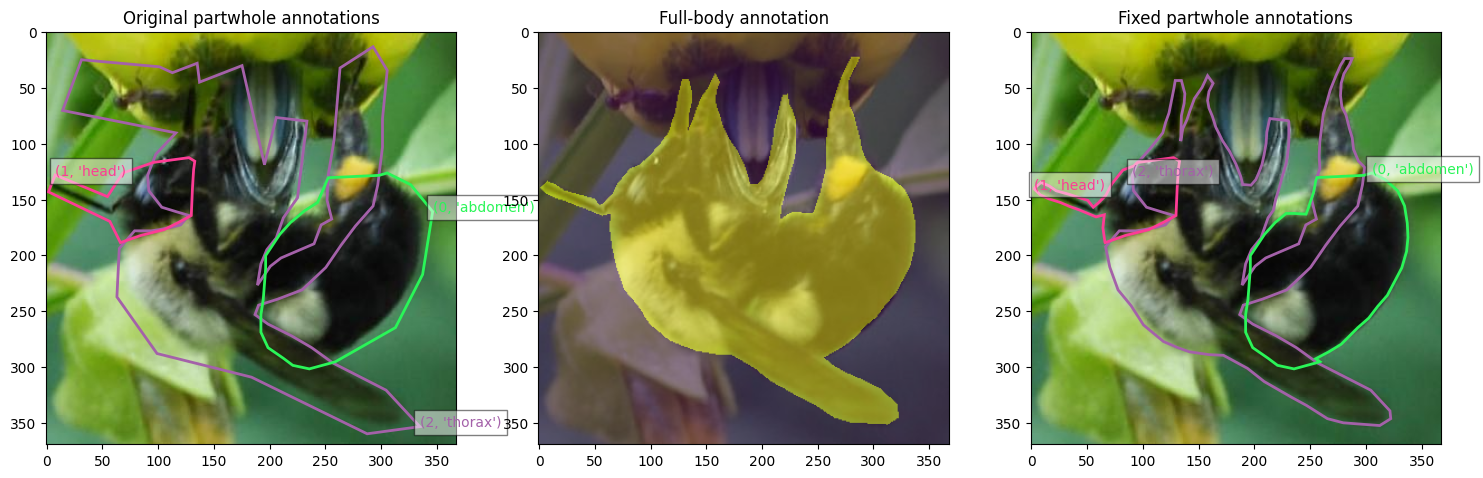

In [8]:
# Get an image and its label
image_file = images[5]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

# Load the image
image = Image.open(image_path)
width, height = image.size

img_path = os.path.join(images_dir, image_file)
yolo_label_path = os.path.join(yolo_labels_dir, label_file)
_, vgg_mask = read_vgg_annotation(vgg_dict[image_file], width, height)
new_polygons = fix_yolo_polygons(yolo_label_path, vgg_dict[image_file], width, height)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
plot_yolo_annotation(img_path, yolo_label_path, axes[0])
plot_vgg_annotation(image, vgg_mask, axes[1])
plot_new_polygons(image, new_polygons, axes[2])

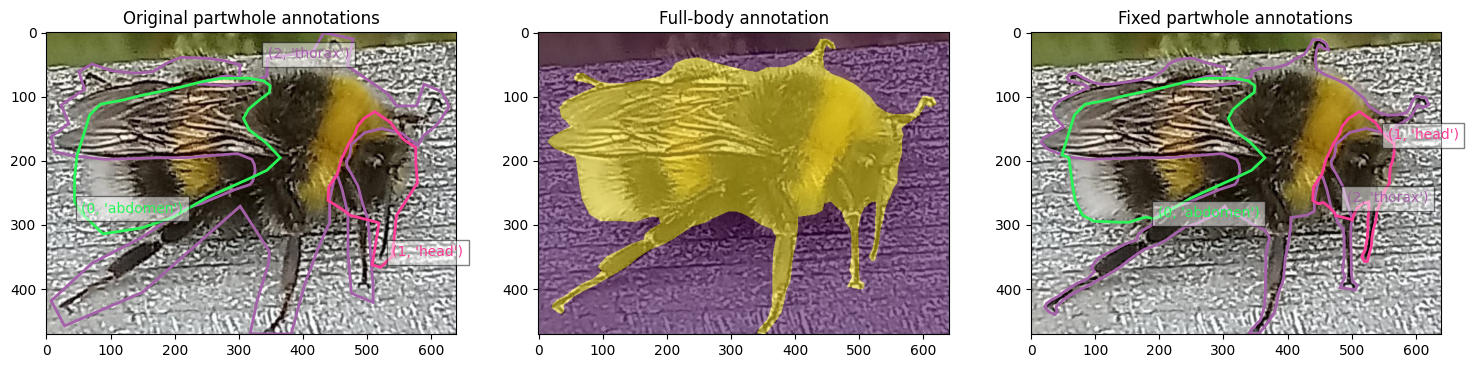

In [9]:
# Get an image and its label
image_file = images[144]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

# Load the image
image = Image.open(image_path)
width, height = image.size

img_path = os.path.join(images_dir, image_file)
yolo_label_path = os.path.join(yolo_labels_dir, label_file)
_, vgg_mask = read_vgg_annotation(vgg_dict[image_file], width, height)
new_polygons = fix_yolo_polygons(yolo_label_path, vgg_dict[image_file], width, height)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
plot_yolo_annotation(img_path, yolo_label_path, axes[0])
plot_vgg_annotation(image, vgg_mask, axes[1])
plot_new_polygons(image, new_polygons, axes[2])

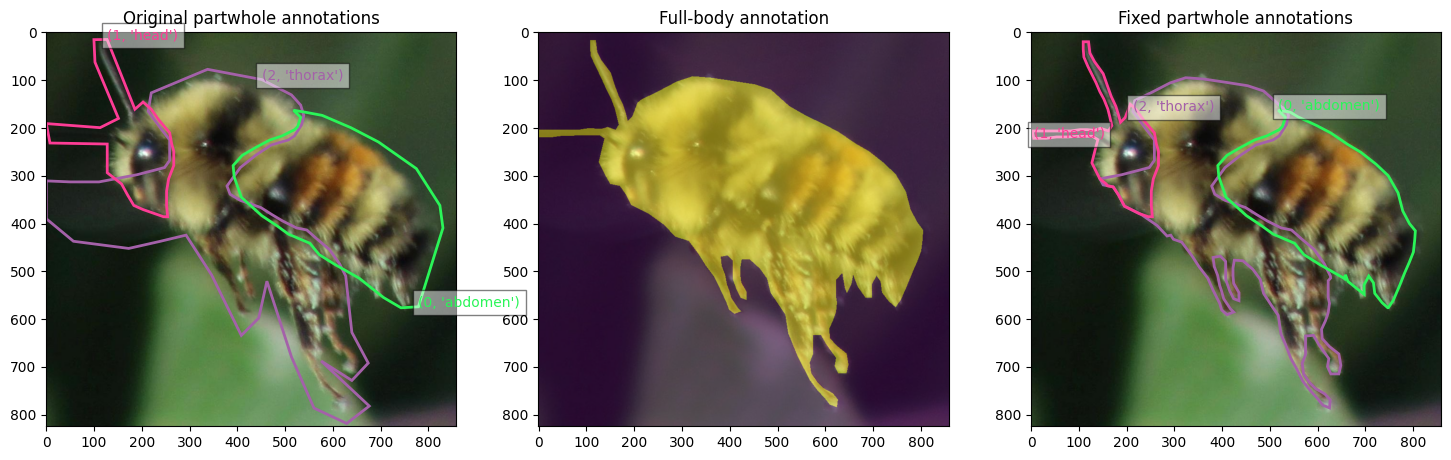

In [10]:
# Get an image and its label
image_file = images[6]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

# Load the image
image = Image.open(image_path)
width, height = image.size

img_path = os.path.join(images_dir, image_file)
yolo_label_path = os.path.join(yolo_labels_dir, label_file)
_, vgg_mask = read_vgg_annotation(vgg_dict[image_file], width, height)
new_polygons = fix_yolo_polygons(yolo_label_path, vgg_dict[image_file], width, height)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
plot_yolo_annotation(img_path, yolo_label_path, axes[0])
plot_vgg_annotation(image, vgg_mask, axes[1])
plot_new_polygons(image, new_polygons, axes[2])

### Make new fixed labels!

In [11]:
prev_labels_dir = yolo_labels_dir
new_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels')
os.makedirs(new_labels_dir, exist_ok=True)
image_filenames = images

for image_file in tqdm(image_filenames):
    # Load the image
    image_path = os.path.join(images_dir, image_file)
    image = Image.open(image_path)
    width, height = image.size
    
    # Get the label paths
    prev_label = os.path.splitext(image_file)[0] + ".txt"
    prev_label_path = os.path.join(prev_labels_dir, prev_label)
    new_label_path = os.path.join(new_labels_dir, prev_label)
    vgg_path = vgg_dict[image_file]

    # Get the new polygons
    new_polygons = fix_yolo_polygons(prev_label_path, vgg_path, width, height)

    updated_lines = []
    for (cls, poly) in new_polygons:
        norm_poly = [(x/width, y/height) for (x,y) in poly]
        norm_poly = list(sum(norm_poly, ()))
        updated_line = " ".join([str(cls)] + list(map(str, norm_poly)))
        updated_lines.append(updated_line)

    # Save new YOLO labels
    with open(new_label_path, 'w') as f:
        f.write("\n".join(updated_lines))
        # print("New annotation saved in:", new_label_path)


  1%|          | 52/5787 [00:01<02:50, 33.65it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels/0QUR0Q3RSQYRXQFRW00020CQM0VRIQZ0U0CR3KFQFKBR3K3Q50K0KQ0020H0QQTRJKJQG0JQRQAR80NR_jpg.rf.35398f3b1ce1cc43d5772c43fe629622.txt


  1%|          | 57/5787 [00:01<02:44, 34.91it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels/106QA05QD06QD04QF0AQLSVQF09QF0MK30GQUKHKAKWQZS4KTKKKA0ZKWKQKOKQKUKRKA0LKT0LK1K_jpg.rf.8ded515926b84ad051b03937b611252a.txt
Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels/BBB_Bombus_affinis_659-1_1_jpg.rf.9784ea2319d14f6f4881cecf6bbda0aa.txt


  1%|▏         | 77/5787 [00:02<02:56, 32.30it/s]

...

 98%|█████████▊| 5698/5787 [02:34<00:02, 38.97it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels/Bombus_mexicanus_GBIF_iNat_2242783851_1-jpg_jpg.rf.1f78c9934094353ac2dc415d7755a09a.txt
Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels/6KHKNKZKTK5QRSAQY05QJ0AQF09QHSWQJ0UQCK1Q1K8KJ0NQY0AQLSPQ9KLKEKSK9K4QV08QB0SKA0PQO02QA00KV06Q_jpg.rf.03c1fc7c5532c5296392ecef42bc7393.txt


 99%|█████████▉| 5742/5787 [02:35<00:00, 47.48it/s]

Invalid full body vgg annotation /home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG/Bombus_bimaculatus/2QD08QT0WQWKXKCKMKTKXKDK8KTK1QDK4KHS6QA0SK106QWKSKDKAQLS4KVKZKT06Q10LK108QC0LK6KHKPK0KB00KPK.json


100%|██████████| 5787/5787 [02:36<00:00, 37.02it/s]


In [13]:
subset = 'valid'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
vgg_annotations_path = r"/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG"

yaml_file = os.path.join(dataset_path, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(dataset_path, subset, 'images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
new_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels')
vgg_annotations = glob.glob(os.path.join(vgg_annotations_path, "*", "*")) # glob.glob(r"/home/c/choton/beemachine/everyday_test/sep26_25/partwhole_yolo_original/VGG/*/*")

images = os.listdir(images_dir)
yolo_labels = os.listdir(yolo_labels_dir)

# Build vgg_dict efficiently
vgg_name_to_path = {}
for vgg_ann in vgg_annotations:
    name = os.path.basename(vgg_ann)[:-5]
    name = name.replace("._", "-_")
    name = name.replace(".jpg", "")
    if name in vgg_name_to_path:
        print(f"Duplicate VGG name: {name}")
    vgg_name_to_path[name] = vgg_ann

vgg_dict = {}
vgg_count = 0
for img in images:
    matched = False
    for name in list(vgg_name_to_path.keys()):
        if name in img:
            if matched:
                print("Duplicate match for image:", img)
            vgg_dict[img] = vgg_name_to_path[name]
            vgg_count += 1
            matched = True

# Check how many vgg annotations are found for the set
images_found = list(vgg_dict.keys())
images_not_found = list(set(images)-set(images_found))
print("VGG count", vgg_count)
print(f"Total images in original dataset: {len(images)}")
print(f"Total vgg annotations found: {len(images_found)}") 
print(f"Images not found: {len(images_not_found)}")

Duplicate VGG name: AZGLNZ8L5ZNHBHIHBHIHOH4HBHXH1HHL5Z7H8ZSLCHKLVH7H5ZSL6ZXHTHNH1ZGLYHUHCH9HFHMLVZ9HHR9H1ZPH1H4H
Duplicate VGG name: AL0ZTLQZNL5RFZIRTZIROZ5RTZJLPLSRCZKROZSRCZIR3ZZZTZZZULJLDZIROZ7RFZMR2LJL9LJL9LZZWLSRULQR2L
Duplicate VGG name: U0S0E0K0M0JR3KAR3KARFKCR3KTQP0DRQQTRJKNR3K9RM01RMQOR60S0SQ00N0H0IQDRE00060FRRQARLQVRG0BRLQ
Duplicate VGG name: HZ9LYLWLKZYZ4RZHERZHPRJZERZHERCLGRDZSRPLQRTZSR9LIROZZZYZZZTZ0RRHPRRH8RZH7ZRHGRCZYLWLZZDZGR
Duplicate match for image: Bombus_distinguendus_GBIF_iNat_3325576534_10-jpg_jpg.rf.6ca297f2bb85ae1fe765ba05ac0172c1.jpg
Duplicate match for image: Bombus_distinguendus_GBIF_iNat_3325576534_16-jpg_jpg.rf.e7f828f7e308c8027b13a7778ecf1989.jpg
Duplicate match for image: Bombus_opifex_GBIF_iNat_2596092695_10-jpg_jpg.rf.53fc3a1244c3e33d4c14b6bfd8ca03e5.jpg
VGG count 1161
Total images in original dataset: 1158
Total vgg annotations found: 1158
Images not found: 0


In [14]:
prev_labels_dir = yolo_labels_dir
new_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels')
os.makedirs(new_labels_dir, exist_ok=True)
image_filenames = images

for image_file in tqdm(image_filenames):
    # Load the image
    image_path = os.path.join(images_dir, image_file)
    image = Image.open(image_path)
    width, height = image.size
    
    # Get the label paths
    prev_label = os.path.splitext(image_file)[0] + ".txt"
    prev_label_path = os.path.join(prev_labels_dir, prev_label)
    new_label_path = os.path.join(new_labels_dir, prev_label)
    vgg_path = vgg_dict[image_file]

    # Get the new polygons
    new_polygons = fix_yolo_polygons(prev_label_path, vgg_path, width, height)

    updated_lines = []
    for (cls, poly) in new_polygons:
        norm_poly = [(x/width, y/height) for (x,y) in poly]
        norm_poly = list(sum(norm_poly, ()))
        updated_line = " ".join([str(cls)] + list(map(str, norm_poly)))
        updated_lines.append(updated_line)

    # Save new YOLO labels
    with open(new_label_path, 'w') as f:
        f.write("\n".join(updated_lines))
        # print("New annotation saved in:", new_label_path)

  3%|▎         | 40/1158 [00:01<00:33, 33.55it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/valid/labels/Bombus_frigidus_13839590_2_1_jpg.rf.b5965c31bca67139c82fd0b2ea7e5325.txt


 17%|█▋        | 195/1158 [00:05<00:25, 37.40it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/valid/labels/Bombus_rubicundus_GBIF_iNat_2237444878_2-jpg_jpg.rf.e1d45661d0b755eba3420c98a10a66aa.txt


 19%|█▉        | 219/1158 [00:06<00:33, 27.87it/s]

...

 94%|█████████▍| 1092/1158 [00:30<00:01, 36.25it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/valid/labels/5HTHXHDH6H6ZMLVZQL8ZKLGZLL8ZLL4ZHL2ZGHEZMH5ZLL1HRLOHXH8ZHL8ZHLVH0LVHEHVZ6HYH6HUZUHJHNHBZXLJH_jpg.rf.cc6747106c60985fae39634a2a5e353e.txt


 98%|█████████▊| 1134/1158 [00:31<00:00, 34.86it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/valid/labels/Bombus_opifex_GBIF_iNat_2238963467_1-jpg_jpg.rf.f8a3bd1e76cca90134b6dfedd2eee3f5.txt


100%|██████████| 1158/1158 [00:32<00:00, 35.29it/s]


In [15]:
subset = 'test'

# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
vgg_annotations_path = r"/home/c/choton/beemachine/datasets/Bee_Full_Body_Segments/VGG"

yaml_file = os.path.join(dataset_path, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(dataset_path, subset, 'images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, subset, 'labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
new_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels')
vgg_annotations = glob.glob(os.path.join(vgg_annotations_path, "*", "*")) # glob.glob(r"/home/c/choton/beemachine/everyday_test/sep26_25/partwhole_yolo_original/VGG/*/*")

images = os.listdir(images_dir)
yolo_labels = os.listdir(yolo_labels_dir)

# Build vgg_dict efficiently
vgg_name_to_path = {}
for vgg_ann in vgg_annotations:
    name = os.path.basename(vgg_ann)[:-5]
    name = name.replace("._", "-_")
    name = name.replace(".jpg", "")
    if name in vgg_name_to_path:
        print(f"Duplicate VGG name: {name}")
    vgg_name_to_path[name] = vgg_ann

vgg_dict = {}
vgg_count = 0
for img in images:
    matched = False
    for name in list(vgg_name_to_path.keys()):
        if name in img:
            if matched:
                print("Duplicate match for image:", img)
            vgg_dict[img] = vgg_name_to_path[name]
            vgg_count += 1
            matched = True

# Check how many vgg annotations are found for the set
images_found = list(vgg_dict.keys())
images_not_found = list(set(images)-set(images_found))
print("VGG count", vgg_count)
print(f"Total images in original dataset: {len(images)}")
print(f"Total vgg annotations found: {len(images_found)}") 
print(f"Images not found: {len(images_not_found)}")

Duplicate VGG name: AZGLNZ8L5ZNHBHIHBHIHOH4HBHXH1HHL5Z7H8ZSLCHKLVH7H5ZSL6ZXHTHNH1ZGLYHUHCH9HFHMLVZ9HHR9H1ZPH1H4H
Duplicate VGG name: AL0ZTLQZNL5RFZIRTZIROZ5RTZJLPLSRCZKROZSRCZIR3ZZZTZZZULJLDZIROZ7RFZMR2LJL9LJL9LZZWLSRULQR2L
Duplicate VGG name: U0S0E0K0M0JR3KAR3KARFKCR3KTQP0DRQQTRJKNR3K9RM01RMQOR60S0SQ00N0H0IQDRE00060FRRQARLQVRG0BRLQ
Duplicate VGG name: HZ9LYLWLKZYZ4RZHERZHPRJZERZHERCLGRDZSRPLQRTZSR9LIROZZZYZZZTZ0RRHPRRH8RZH7ZRHGRCZYLWLZZDZGR
Duplicate match for image: Bombus_opifex_GBIF_iNat_2596092695_15-jpg_jpg.rf.045cebc26e98d2527e1e786b107edc9d.jpg
Duplicate match for image: Bombus_opifex_GBIF_iNat_2596092695_14-jpg_jpg.rf.72b6489a2b9058dae010297ec0bafb09.jpg
Duplicate match for image: Bombus_morio_GBIF_iNat_2576312696_16-jpg_jpg.rf.a69e7a97db957c5469653415d5c3f192.jpg
VGG count 774
Total images in original dataset: 771
Total vgg annotations found: 771
Images not found: 0


In [16]:
prev_labels_dir = yolo_labels_dir
new_labels_dir = os.path.join(dataset_path, subset, 'fixed_labels')
os.makedirs(new_labels_dir, exist_ok=True)
image_filenames = images

for image_file in tqdm(image_filenames):
    # Load the image
    image_path = os.path.join(images_dir, image_file)
    image = Image.open(image_path)
    width, height = image.size
    
    # Get the label paths
    prev_label = os.path.splitext(image_file)[0] + ".txt"
    prev_label_path = os.path.join(prev_labels_dir, prev_label)
    new_label_path = os.path.join(new_labels_dir, prev_label)
    vgg_path = vgg_dict[image_file]

    # Get the new polygons
    new_polygons = fix_yolo_polygons(prev_label_path, vgg_path, width, height)

    updated_lines = []
    for (cls, poly) in new_polygons:
        norm_poly = [(x/width, y/height) for (x,y) in poly]
        norm_poly = list(sum(norm_poly, ()))
        updated_line = " ".join([str(cls)] + list(map(str, norm_poly)))
        updated_lines.append(updated_line)

    # Save new YOLO labels
    with open(new_label_path, 'w') as f:
        f.write("\n".join(updated_lines))
        # print("New annotation saved in:", new_label_path)

 21%|██        | 162/771 [00:04<00:19, 31.58it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/test/labels/8RZH2RHH7RBLLZPLHZELJL1LYLJZMRKH6RHHQZAL5RHH0RHHSZQH5RCL5RCLHZNL7R9LRZ6LFL6LZZNLQRNLMRYZQR_jpg.rf.acf718d439febe7b3fc2e4b8128f5a9d.txt


 26%|██▋       | 203/771 [00:05<00:14, 40.16it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/test/labels/BBW_Bombus_appositus_44032_dcdc8747-2d67-4b6c-867b-50109d791148_1_jpg.rf.b9ec59c99f0933a8b036b63bd2157913.txt


 50%|████▉     | 383/771 [00:11<00:08, 43.25it/s]

...

 94%|█████████▍| 728/771 [00:22<00:01, 27.07it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/test/labels/1QO0VQZS9QHSAQRS2QV0ZKUKKKWK6QO04QPKGQ309QVKLK2KHKB0EQD0EQC0PQB02QA08QD02QB0LK10_1_jpg.rf.7be2eba069dbffbd51e186869b05e9aa.txt
Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/test/labels/1QO0VQZS9QHSAQRS2QV0ZKUKKKWK6QO04QPKGQ309QVKLK2KHKB0EQD0EQC0PQB02QA08QD02QB0LK10_1_jpg.rf.7be2eba069dbffbd51e186869b05e9aa.txt


 98%|█████████▊| 754/771 [00:23<00:00, 34.43it/s]

Invalid bodypart for yolo annotation /home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/test/labels/BBW_Bombus_appositus_32725_a2b426e4-5ed3-4751-97e8-6ace99fcefaa_1_jpg.rf.44c9f28c964c63c89fba9738e5f69556.txt


100%|██████████| 771/771 [00:23<00:00, 32.78it/s]
